# Kendall Tau test

In [25]:
import os
import glob
import json
import numpy as np
import pandas as pd
from scipy.stats import kendalltau

# --- Extract and Aggregate Bid-Value Data ---

def extract_bid_value_pairs(row):
    """Extract bid and value lists from a row."""
    return row.get("Values", []), row.get("Bids", [])

def aggregate_bid_value_pairs(df):
    """Aggregates bid-value pairs across all rows."""
    values, bids = [], []
    for _, row in df.iterrows():
        v_list, b_list = extract_bid_value_pairs(row)
        values.extend(v_list)
        bids.extend(b_list)
    return np.array(values), np.array(bids)

# --- Kendall Tau Test for Monotonicity ---

def kendall_tau_test(df):
    """Computes Kendall's Tau to test for bid monotonicity."""
    values, bids = aggregate_bid_value_pairs(df)
    if len(values) == 0:
        print("No bid-value data available.")
        return None

    tau, p_value = kendalltau(values, bids, variant='b')
    # print(p_value)
    print(f"Kendall's Tau: {tau:.3f}, p-value: {p_value:.5f}")
    return tau, p_value

# --- Load and Process Data ---

def create_dataframe(json_files):
    """Processes JSON files into a DataFrame."""
    all_rounds = []
    for file in json_files:
        with open(file, 'r') as f:
            data = json.load(f)
        for round_data in data.values():
            all_rounds.append({
                'Values': round_data.get('value', []),
                'Bids': [int(bid['bid']) for bid in round_data['history']['bidding history']]
            })
    return pd.DataFrame(all_rounds)

def process_experiment(directory):
    """Loads JSON files from a directory and runs the Kendall Tau test."""
    json_files = glob.glob(os.path.join(directory, "*.json"))
    if not json_files:
        print(f"No JSON files found in {directory}")
        return None

    df = create_dataframe(json_files)
    return df, kendall_tau_test(df)

# --- Run the Test on Private Value Auction Data ---

if __name__ == "__main__":
    base_dir = '/Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10'
    experiments = {
        "private_first": "private_first_price",
        "private_second": "private_second_price",
        "private_third": "private_third_price",
        "private_all_pay": "private_all_pay"
    }

    for exp_name, subdir in experiments.items():
        print(f"\nProcessing {exp_name}:")
        df, results = process_experiment(os.path.join(base_dir, subdir))
        results



Processing private_first:
Kendall's Tau: 0.672, p-value: 0.00000

Processing private_second:
Kendall's Tau: 0.666, p-value: 0.00000

Processing private_third:
Kendall's Tau: 0.671, p-value: 0.00000

Processing private_all_pay:
Kendall's Tau: 0.660, p-value: 0.00000


# Learning and skewness tests (for David)

/Users/avshah/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Processing private_first from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/private_first_price


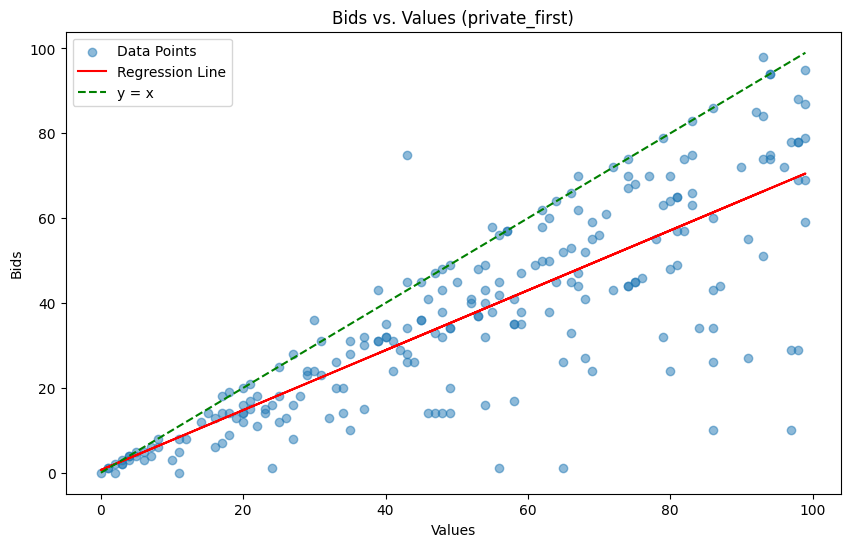

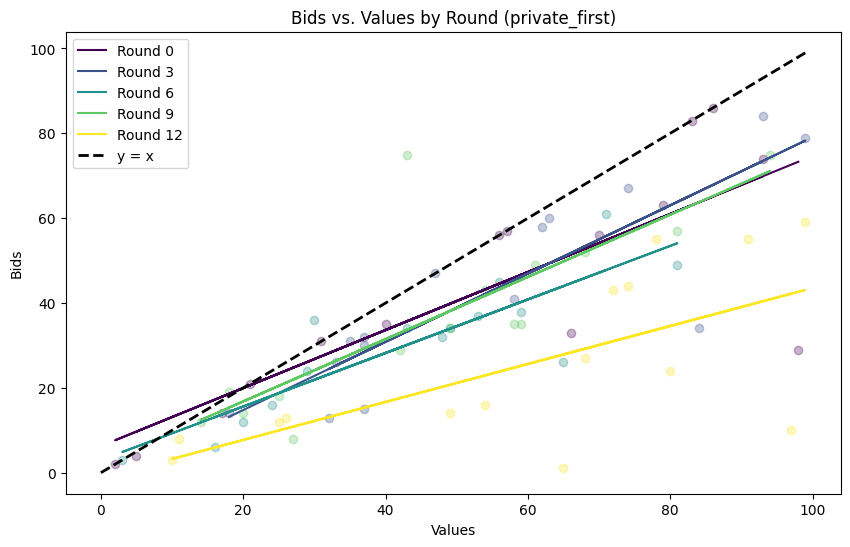

Processing private_second from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/private_second_price


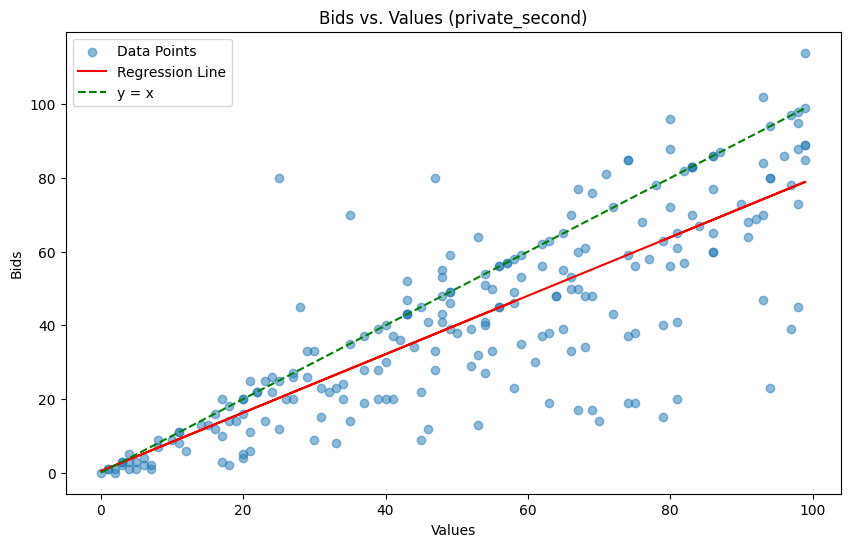

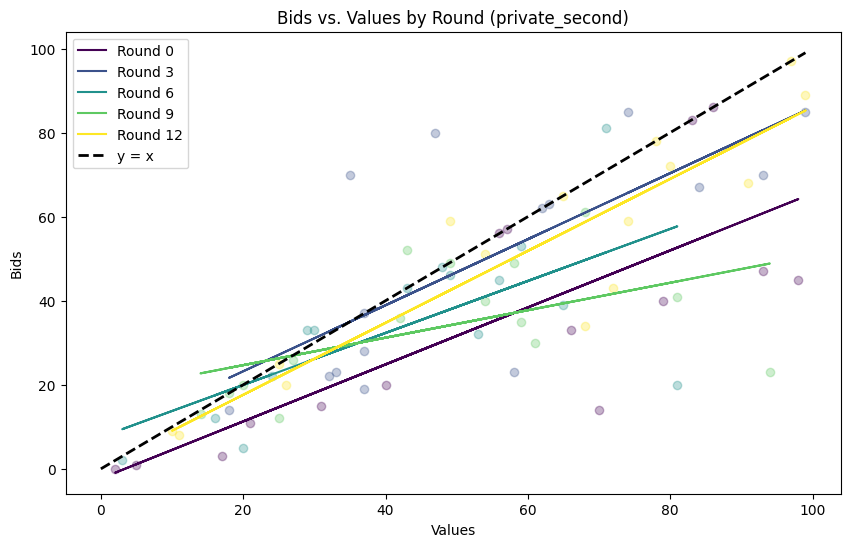

Processing private_third from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/private_third_price


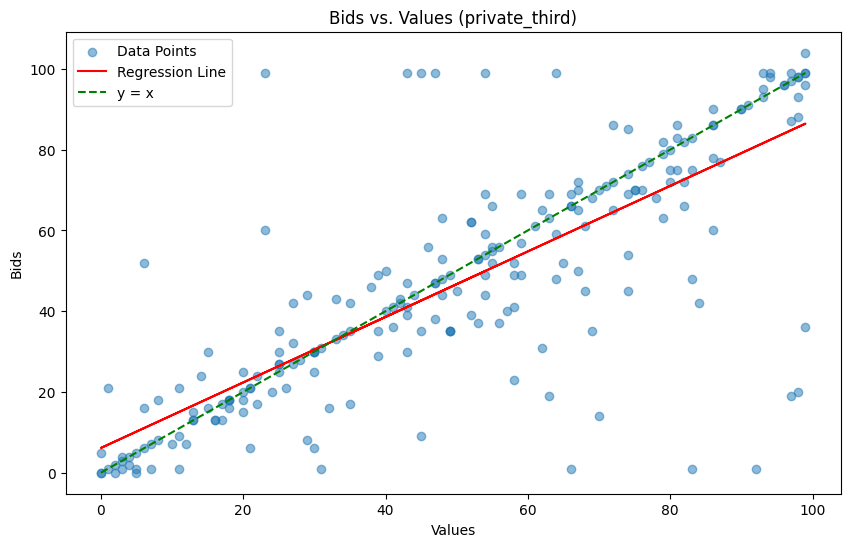

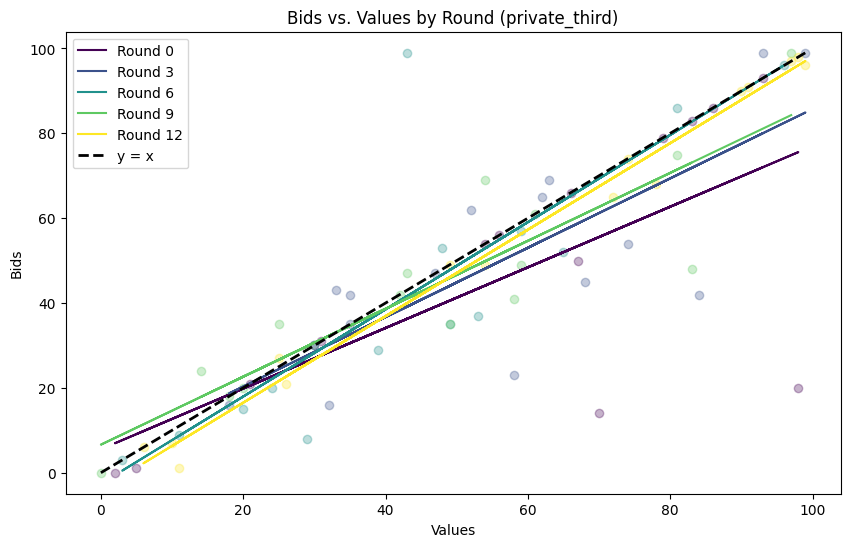

Processing private_all_pay from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/private_all_pay


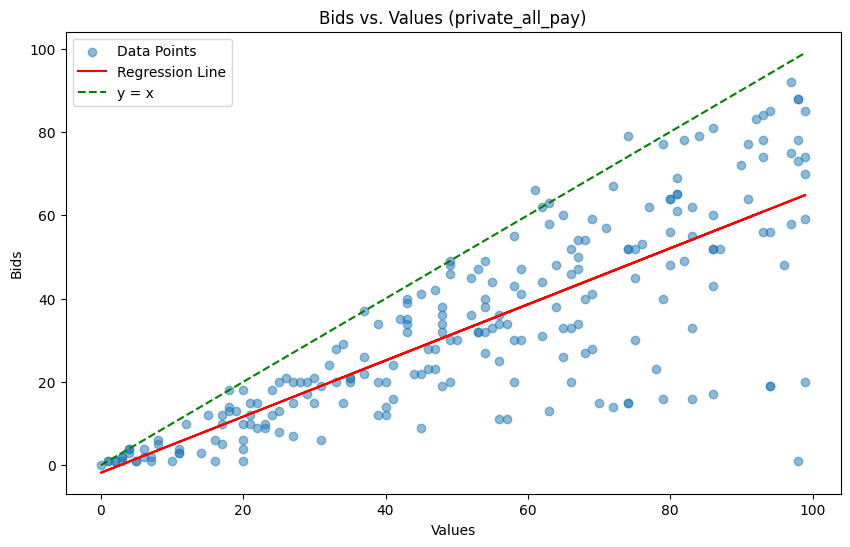

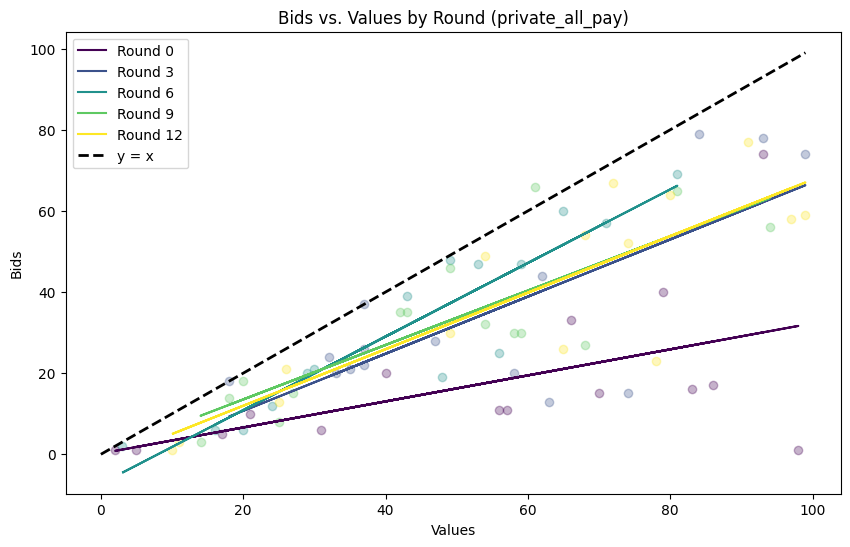

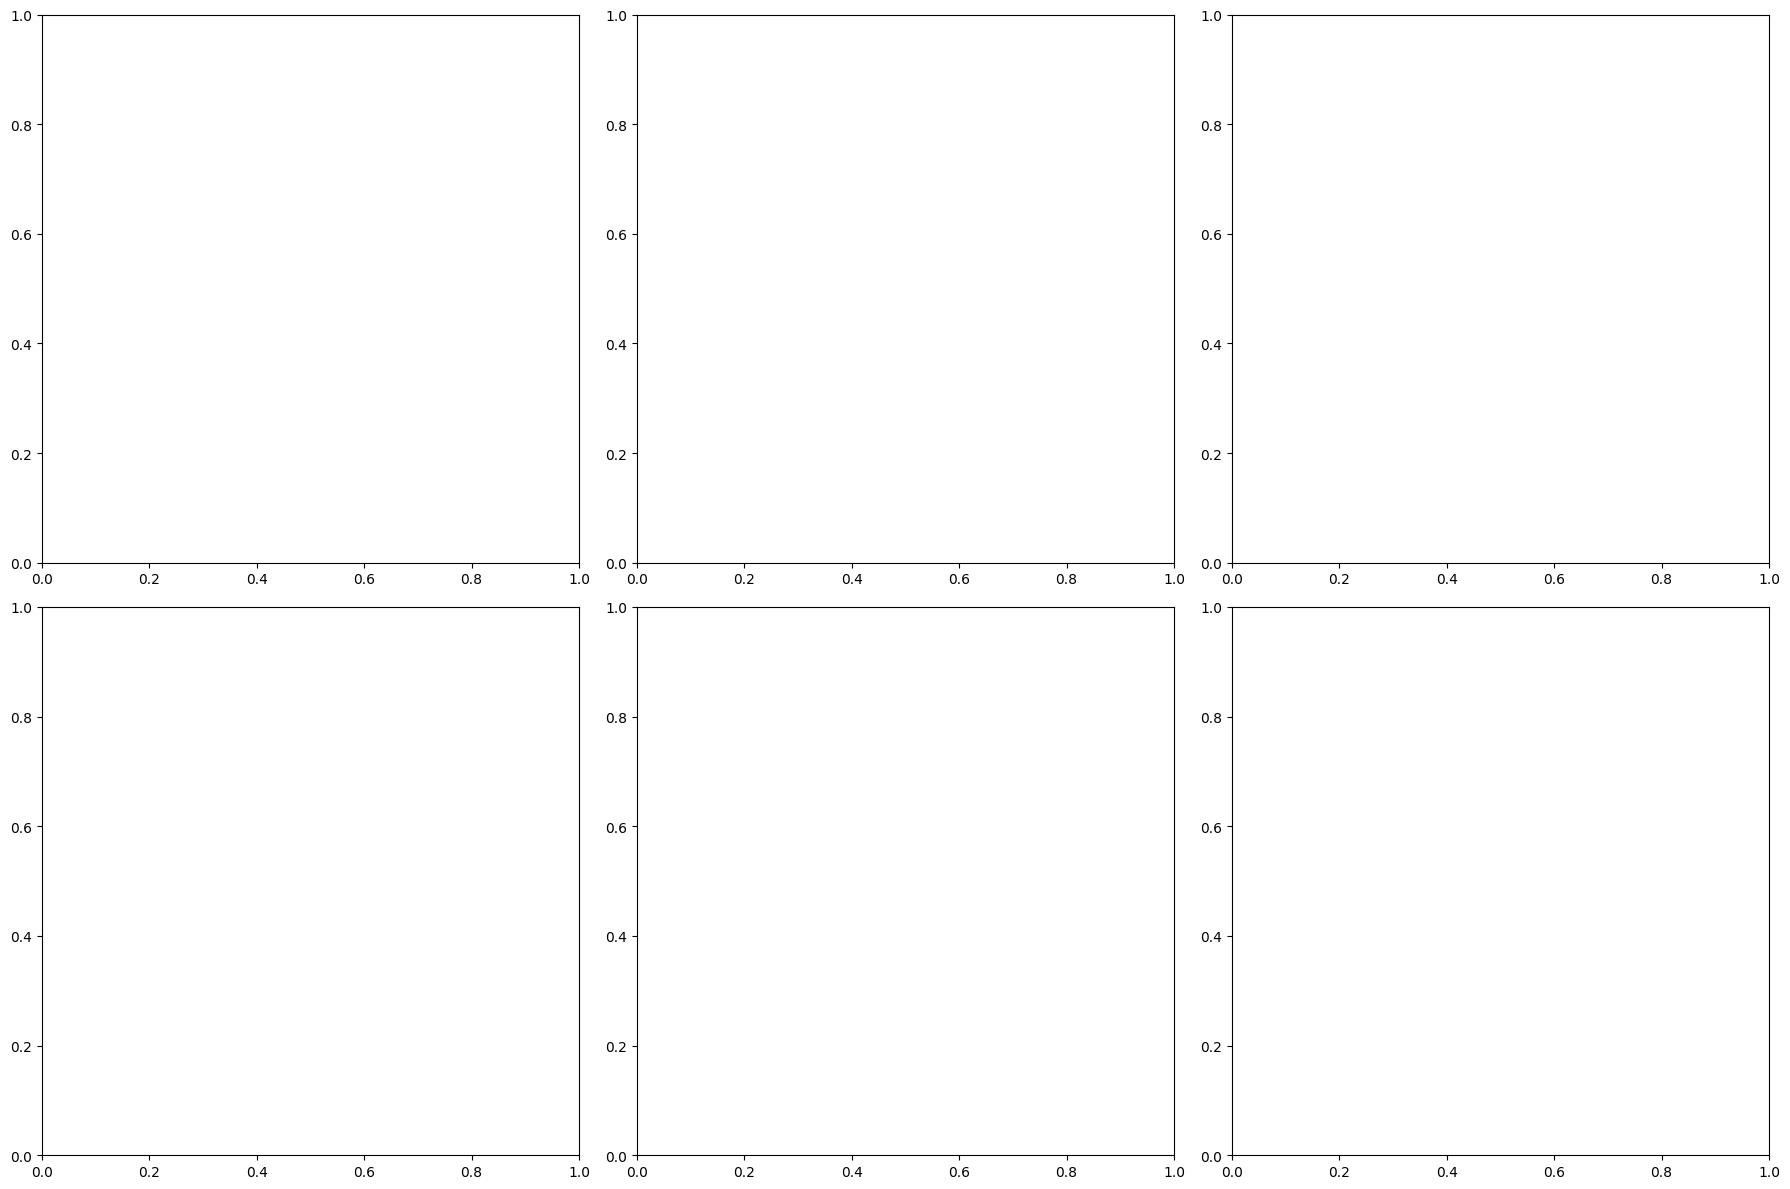

Regression and Skewness Test Results:
     Experiment  Observations  Proportional Bias (α) Proportional Bias p-value  Noise (σ)  Intercept Intercept p-value  Slope Slope p-value  R-squared  Residual Skew  Skew Test Statistic Skew Test p-value
  private_first           225                 -0.285                  3.6e-114     14.037      0.638             0.746  0.706       3.8e-55      0.667         -0.952               -5.180           2.2e-07
 private_second           225                 -0.200                  6.7e-115     15.562      0.435             0.842  0.793       5.0e-56      0.673         -0.349               -2.148             0.032
  private_third           225                 -0.097                  8.0e-109     18.397      6.130             0.013  0.811       5.4e-49      0.622         -0.629               -3.683           2.3e-04
private_all_pay           225                 -0.353                  1.7e-105     14.013     -1.800             0.361  0.673       2.5e-52   

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import skew, skewtest
import warnings

warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated')

# --- Helper Functions for Data Aggregation ---

def extract_bid_value_pairs(row):
    """Extract bid and value lists from a row."""
    values = row.get("Values", [])
    bids = row.get("Bids", [])
    return values, bids

def aggregate_bid_value_pairs(df):
    """
    Aggregates bid and value pairs across all rows.
    
    Returns:
        X: numpy array of values.
        y: numpy array of bids.
    """
    bid_values = []
    bids = []
    for _, row in df.iterrows():
        values, bid_list = extract_bid_value_pairs(row)
        for value, bid in zip(values, bid_list):
            bid_values.append(value)
            bids.append(bid)
    return np.array(bid_values), np.array(bids)

# --- Original Plotting Functions ---

def plot_bid_value(df, label=""):
    """
    Plots bid vs. value along with a regression line and the y = x reference line.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        print(f"No bid-value data for {label}.")
        return
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    regression_line = model.predict(X_with_const)
    
    x_range = np.linspace(X.min(), X.max(), 100)
    y_line = x_range
    
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, alpha=0.5, label="Data Points")
    plt.plot(X, regression_line, color='red', label="Regression Line")
    plt.plot(x_range, y_line, color='green', linestyle='dashed', label="y = x")
    plt.xlabel("Values")
    plt.ylabel("Bids")
    plt.title(f"Bids vs. Values ({label})")
    plt.legend()
    plt.show()

def plot_by_round(df, step=5, label=""):
    """
    Plots bid-value pairs and regression lines for selected rounds.
    """
    rounds_sorted = sorted(df["Round"].dropna().unique())
    if not rounds_sorted:
        print(f"No rounds found for {label}.")
        return
    selected_rounds = rounds_sorted[::step]
    plt.figure(figsize=(10,6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(selected_rounds)))
    for round_num, color in zip(selected_rounds, colors):
        group = df[df["Round"] == round_num]
        bid_values = []
        bids = []
        for _, row in group.iterrows():
            values, bid_list = extract_bid_value_pairs(row)
            for value, bid in zip(values, bid_list):
                bid_values.append(value)
                bids.append(bid)
        if len(bid_values) == 0:
            continue
        X = np.array(bid_values)
        y_vals = np.array(bids)
        X_with_const = sm.add_constant(X)
        model = sm.OLS(y_vals, X_with_const).fit()
        regression_line = model.predict(X_with_const)
        plt.scatter(X, y_vals, color=color, alpha=0.3)
        plt.plot(X, regression_line, color=color, label=f"Round {round_num}")
    overall_X, _ = aggregate_bid_value_pairs(df)
    if len(overall_X) > 0:
        x_range_all = np.linspace(overall_X.min(), overall_X.max(), 100)
        plt.plot(x_range_all, x_range_all, color='black', linestyle='dashed', linewidth=2, label="y = x")
    plt.xlabel("Values")
    plt.ylabel("Bids")
    plt.title(f"Bids vs. Values by Round ({label})")
    plt.legend()
    plt.show()

def plot_percent_error(df, label=""):
    """
    Computes and plots the average percent error (bid - value relative to value) by round.
    """
    def calculate_percent_error(row):
        errors = []
        values = row.get("Values", [])
        bids = row.get("Bids", [])
        for value, bid in zip(values, bids):
            if value != 0:
                errors.append((bid - value) / value)
            else:
                errors.append(np.nan)
        return errors
    
    df = df.copy()
    df["Percent Errors"] = df.apply(calculate_percent_error, axis=1)
    expanded_df = df.explode("Percent Errors")
    grouped = expanded_df.groupby("Round")["Percent Errors"].agg(["mean", "std"]).reset_index()
    plt.figure(figsize=(10,6))
    plt.errorbar(grouped["Round"], grouped["mean"], yerr=grouped["std"], fmt='o-', capsize=5, label="Avg Percent Error")
    plt.axhline(y=0, color='black', linestyle='dashed', linewidth=1)
    plt.xlabel("Round")
    plt.ylabel("Average Percent Error")
    plt.title(f"Average Percent Error by Round ({label})")
    plt.legend()
    plt.show()


def plot_bid_value_subplot(ax, df, label):
    """
    Helper function to plot bid vs. value on a given subplot (ax).
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        ax.set_title(f"No Data for {label}")
        return
    
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    regression_line = model.predict(X_with_const)

    x_range = np.linspace(X.min(), X.max(), 100)
    y_line = x_range

    ax.scatter(X, y, alpha=0.5, label="Data Points")
    ax.plot(X, regression_line, color='red', label="Regression Line")
    ax.plot(x_range, y_line, color='green', linestyle='dashed', label="y = x")
    ax.set_xlabel("Values")
    ax.set_ylabel("Bids")
    ax.set_title(f"Bids vs. Values ({label})")
    ax.legend()

# --- Additional Plot: Histogram of Bid - Value ---

def plot_bid_value_diff_histogram(df, label=""):
    """
    Plots a histogram of the differences (bid - value) for all bid-value pairs.
    """
    differences = []
    for _, row in df.iterrows():
        values, bid_list = extract_bid_value_pairs(row)
        for value, bid in zip(values, bid_list):
            differences.append(bid - value)
    if len(differences) == 0:
        print(f"No bid-value differences to plot for {label}.")
        return
    plt.figure(figsize=(10,6))
    sns.histplot(differences, bins=20, kde=True, color='skyblue')
    plt.xlabel("Bid - Value")
    plt.xlim(-60,60)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Bid - Value ({label})")
    plt.show()

# --- Regression and Skewness Analysis ---

def compute_regression_and_skew_tests(df):
    """
    Aggregates bid-value pairs, fits a regression (bids on values), computes the regression parameters,
    and then calculates the skewness of the residuals along with a formal skew test.
    
    Returns:
        dict with:
          - Observations,
          - Intercept, intercept p-value,
          - Slope, slope p-value,
          - R-squared,
          - Residual skew,
          - Skew test statistic and p-value.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        return None

    # Regression: bids = intercept + slope * value
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    intercept = model.params[0]
    slope = model.params[1]
    intercept_p = model.pvalues[0]
    slope_p = model.pvalues[1]
    r_squared = model.rsquared

    # Residuals
    residuals = y - model.predict(X_with_const)

    # Skewness calculations
    residual_skew = skew(residuals)
    skew_test_stat, skew_test_p = skewtest(residuals)

    return {
        "Observations": len(y),
        "Intercept": intercept,
        "Intercept p-value": intercept_p,
        "Slope": slope,
        "Slope p-value": slope_p,
        "R-squared": r_squared,
        "Residual Skew": residual_skew,
        "Skew Test Statistic": skew_test_stat,
        "Skew Test p-value": skew_test_p
    }

# def report_results_table(all_dfs):
#     results = []
#     for exp_name, df in all_dfs.items():
#         stats_dict = compute_regression_and_skew_tests(df)
#         if stats_dict is None:
#             continue
#         stats_dict["Experiment"] = exp_name
#         results.append(stats_dict)
#     table = pd.DataFrame(results)
    
#     # Ensure the "Observations" column is an integer.
#     table["Observations"] = table["Observations"].astype(int)
    
#     # Round key numerical columns for neatness.
#     table["Intercept"] = table["Intercept"].round(3)
#     table["Slope"] = table["Slope"].round(3)
#     table["R-squared"] = table["R-squared"].round(3)
#     table["Residual Skew"] = table["Residual Skew"].round(3)
#     table["Skew Test Statistic"] = table["Skew Test Statistic"].round(3)
    
#     # Format p-values: use scientific notation if below 0.001; otherwise, show three decimals.
#     def format_p(p):
#         return f"{p:.1e}" if p < 0.001 else f"{p:.3f}"
#     table["Intercept p-value"] = table["Intercept p-value"].apply(format_p)
#     table["Slope p-value"] = table["Slope p-value"].apply(format_p)
#     table["Skew Test p-value"] = table["Skew Test p-value"].apply(format_p)
    
#     # Reorder columns for a cleaner display.
#     desired_order = ["Experiment", "Observations", "Intercept", "Intercept p-value",
#                      "Slope", "Slope p-value", "R-squared", "Residual Skew", 
#                      "Skew Test Statistic", "Skew Test p-value"]
#     table = table[desired_order]
#     return table

def compute_regression_and_skew_tests(df):
    """
    Fits bid = (1 + α)value + ε model and computes:
    - Proportional bias (α)
    - Noise (std of ε)
    Also includes original regression statistics and skewness tests.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        return None

    # Fit proportional bias model: bid = (1 + α)value + ε
    model_prop = sm.OLS(y, X).fit()
    alpha = model_prop.params[0] - 1  # proportional bias
    epsilon = model_prop.resid
    noise = np.std(epsilon)
    alpha_p = model_prop.pvalues[0]

    # Original regression metrics (keeping for completeness)
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    
    # Skewness of residuals
    residual_skew = skew(model.resid)
    skew_test_stat, skew_test_p = skewtest(model.resid)

    return {
        "Observations": len(y),
        "Proportional Bias (α)": alpha,
        "Proportional Bias p-value": alpha_p,
        "Noise (σ)": noise,
        "Intercept": model.params[0],
        "Intercept p-value": model.pvalues[0],
        "Slope": model.params[1],
        "Slope p-value": model.pvalues[1],
        "R-squared": model.rsquared,
        "Residual Skew": residual_skew,
        "Skew Test Statistic": skew_test_stat,
        "Skew Test p-value": skew_test_p
    }

def report_results_table(all_dfs):
    results = []
    for exp_name, df in all_dfs.items():
        stats_dict = compute_regression_and_skew_tests(df)
        if stats_dict is None:
            continue
        stats_dict["Experiment"] = exp_name
        results.append(stats_dict)
    table = pd.DataFrame(results)
    
    # Ensure the "Observations" column is an integer
    table["Observations"] = table["Observations"].astype(int)
    
    # Round numerical columns
    table["Proportional Bias (α)"] = table["Proportional Bias (α)"].round(3)
    table["Noise (σ)"] = table["Noise (σ)"].round(3)
    table["Intercept"] = table["Intercept"].round(3)
    table["Slope"] = table["Slope"].round(3)
    table["R-squared"] = table["R-squared"].round(3)
    table["Residual Skew"] = table["Residual Skew"].round(3)
    table["Skew Test Statistic"] = table["Skew Test Statistic"].round(3)
    
    # Format p-values
    def format_p(p):
        return f"{p:.1e}" if p < 0.001 else f"{p:.3f}"
    
    table["Proportional Bias p-value"] = table["Proportional Bias p-value"].apply(format_p)
    table["Intercept p-value"] = table["Intercept p-value"].apply(format_p)
    table["Slope p-value"] = table["Slope p-value"].apply(format_p)
    table["Skew Test p-value"] = table["Skew Test p-value"].apply(format_p)
    
    # Reorder columns to prioritize new metrics
    desired_order = [
        "Experiment", "Observations", 
        "Proportional Bias (α)", "Proportional Bias p-value",
        "Noise (σ)", 
        "Intercept", "Intercept p-value",
        "Slope", "Slope p-value", 
        "R-squared", "Residual Skew", 
        "Skew Test Statistic", "Skew Test p-value"
    ]
    
    table = table[desired_order]
    return table


# --- Data Ingestion Functions ---

def create_dataframe(json_files, exp_name):
    """
    Processes multiple JSON files into a single DataFrame for an intervention experiment.
    """
    all_rounds = []
    bidder_mapping = {
        'Bidder Andy': 0, 'Bidder Betty': 1, 'Bidder Charles': 2,
        'Bidder David': 3, 'Bidder Ethel': 4, 'Bidder Florian': 5
    }
    for file_idx, file in enumerate(json_files):
        try:
            with open(file, 'r') as f:
                data = json.load(f)
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue
        for round_key, round_data in data.items():
            if round_key.startswith('round_'):
                winner_name = round_data['history']['winner']['winner']
                winner_index = bidder_mapping.get(winner_name, None)
                try:
                    bids = [int(bid['bid']) for bid in round_data['history']['bidding history']]
                except Exception as e:
                    print(f"Error processing bids in {file}: {e}")
                    bids = []
                round_dict = {
                    'exp_name': exp_name,
                    'file_id': file_idx,
                    'Round': round_data.get('round', None),
                    'Values': round_data.get('value', []),
                    'Bids': bids,
                    'Winner Index': winner_index,
                    'Winner Name': winner_name,
                    'Realized Common Value': round_data.get('common', 'No common value'),
                    'Bid Paid by Winner': int(round_data['history']['winner'].get('price', 0)),
                    'Winner Total Profit': (round_data['profit'][winner_index]
                                            if (winner_index is not None and 
                                                'profit' in round_data and 
                                                len(round_data['profit']) > winner_index)
                                            else None)
                }
                all_rounds.append(round_dict)
    return pd.DataFrame(all_rounds)

def process_intervention_experiment(exp_name, directory):
    """
    Automatically discovers JSON files in the specified directory and creates a DataFrame.
    """
    pattern = os.path.join(directory, "*.json")
    json_files = glob.glob(pattern)
    if not json_files:
        print(f"No JSON files found in directory: {directory}")
        return None
    return create_dataframe(json_files, exp_name)

# --- Main Execution ---

def main():
    """
    Defines the intervention experiments, processes each experiment,
    generates the original plots, an extra histogram of bid-value differences,
    and then compiles and prints a summary table of regression and skew tests.
    """
    base_dir = '/Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10'
    interventions = {
        "private_first": "private_first_price",
        "private_second": "private_second_price",
        "private_third": "private_third_price",
        "private_all_pay": "private_all_pay", 
        # "menu_intervention": "intervention_menu",
        # "proxy_intervention": "intervention_proxy_breitmoser",
        # "nash_intervention": "intervention_nash_deviation",
        # "dominant_strat_intervention": "intervention_NE_strat_reveal",
        # "wrong_strat_intervention": "intervention_wrong_strat_reveal",
        # "risk_intervention": "intervention_risk_neutrality"
    }
    
    all_dfs = {}
    
    # Process each experiment and generate plots.
    for exp_name, subdir in interventions.items():
        directory = os.path.join(base_dir, subdir)
        print(f"Processing {exp_name} from {directory}")
        df = process_intervention_experiment(exp_name, directory)
        if df is None:
            continue
        all_dfs[exp_name] = df
        
        # Generate the original plots.
        plot_bid_value(df, label=exp_name)
        plot_by_round(df, step=3, label=exp_name)
        # plot_percent_error(df, label=exp_name)
        
        # Generate additional histogram of bid - value differences.
        # plot_bid_value_diff_histogram(df, label=exp_name)
    
    # --- Define Experiments to Include in the Panel ---
    selected_experiments = [
        "menu_intervention", "proxy_intervention", "nash_intervention",
        "dominant_strat_intervention", "wrong_strat_intervention", "risk_intervention"
    ]

    # --- Create the Panel Plot ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns

    for ax, exp_name in zip(axes.flatten(), selected_experiments):
        if exp_name in all_dfs:
            plot_bid_value_subplot(ax, all_dfs[exp_name], label=exp_name)

    plt.tight_layout()
    # plt.savefig("Figs/bid_value_panel.png", dpi=300)  # Save for LaTeX
    plt.show()


    # Compile and print the summary table of regression and skew tests.
    results_table = report_results_table(all_dfs)
    print("Regression and Skewness Test Results:")
    print(results_table.to_string(index=False))
    
    return all_dfs

if __name__ == "__main__":
    all_dfs = main()
    all_dfs


# CRRA calculations

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import minimize

def calculate_risk_coefficients(all_dfs):
    """Calculate CARA and CRRA coefficients for all three auction formats"""
    results = {}
    
    # Process each auction format
    results['FPSB'] = process_fpsb(all_dfs["private_first"])
    results['TPSB'] = process_tpsb(all_dfs["private_third"])
    results['AllPay'] = process_allpay(all_dfs["private_all_pay"])
    
    return results

def extract_bid_value_pairs(df):
    """Extract bid-value pairs from dataframe"""
    values = []
    bids = []
    for _, row in df.iterrows():
        v_list = row.get("Values", [])
        b_list = row.get("Bids", [])
        for v, b in zip(v_list, b_list):
            if v > 0 and b > 0:  # Avoid division by zero
                values.append(v)
                bids.append(b)
    
    return np.array(values), np.array(bids)

def process_fpsb(df):
    """Process first-price sealed-bid auction data"""
    values, bids = extract_bid_value_pairs(df)
    n = 3  # Number of bidders
    
    # Calculate CRRA coefficients (analytical approach)
    # For FPSB: b(v) = [(n-1)/(n-1+r)]·v, which implies r = (n-1)*(v/b - 1)
    individual_r = (n-1) * (values/bids - 1)
    crra_estimate = np.median(individual_r)
    
    # Calculate CARA coefficient (numerical optimization)
    # For FPSB with CARA, there's no simple analytical form, so we use numerical optimization
    def cara_bid_function(v, lambda_):
        """CARA bidding function for FPSB (approximate numerical solution)"""
        if lambda_ == 0:  # Risk neutral case
            return (n-1)/n * v
        
        # Numerical approximation for CARA bidding with uniform values on [0,99]
        return v - (1/lambda_) * (1 - np.exp(-lambda_ * v * (n-1)/n))
    
    def cara_objective(lambda_):
        """Objective function for CARA optimization (sum of squared errors)"""
        predicted_bids = np.array([cara_bid_function(v, lambda_) for v in values])
        return np.sum((bids - predicted_bids)**2)
    
    # Find the CARA coefficient that minimizes the sum of squared errors
    cara_result = minimize(cara_objective, x0=0.01, bounds=[(0, 1)])
    cara_estimate = cara_result.x[0]
    
    # Calculate regression statistics for comparison
    X = sm.add_constant(values)
    model = sm.OLS(bids, X).fit()
    
    return {
        'format': 'First-Price Sealed-Bid',
        'crra': crra_estimate,
        'cara': cara_estimate,
        'regression_slope': model.params[1],
        'regression_intercept': model.params[0],
        'r_squared': model.rsquared,
        'theoretical_risk_neutral_slope': (n-1)/n,  # 2/3 for n=3
        'num_observations': len(values)
    }

def process_tpsb(df):
    """Process third-price sealed-bid auction data"""
    values, bids = extract_bid_value_pairs(df)
    n = 3  # Number of bidders
    
    # Calculate CRRA coefficients
    # For TPSB: b(v) = v * (n-1)/(n-2) * [(n-2+r)/(n-1+r)]
    # Which means r can be calculated from: r = (n-1)*(v/b)*(n-2+r)/(n-2) - (n-1)
    # This is harder to solve directly, so we use optimization
    
    def crra_tpsb_bid_function(v, r):
        """CRRA bidding function for TPSB"""
        if r == 0:  # Risk neutral case
            return (n-1)/(n-2) * v  # 2v for n=3
        return v * (n-1)/(n-2) * ((n-2)/(n-2+r))
    
    def crra_objective(r):
        """Objective function for CRRA optimization (sum of squared errors)"""
        predicted_bids = np.array([crra_tpsb_bid_function(v, r) for v in values])
        return np.sum((bids - predicted_bids)**2)
    
    # Find the CRRA coefficient that minimizes the sum of squared errors
    crra_result = minimize(crra_objective, x0=0.5, bounds=[(0, 10)])
    crra_estimate = crra_result.x[0]
    
    # Calculate CARA coefficient
    def cara_tpsb_bid_function(v, lambda_):
        """CARA bidding function for TPSB"""
        if lambda_ == 0:  # Risk neutral case
            return (n-1)/(n-2) * v  # 2v for n=3
        
        # From theory: b(v) = v + (1/λ)ln[1 + λv/(n-2)]
        return v + (1/lambda_) * np.log(1 + lambda_*v/(n-2))
    
    def cara_objective(lambda_):
        """Objective function for CARA optimization (sum of squared errors)"""
        predicted_bids = np.array([cara_tpsb_bid_function(v, lambda_) for v in values])
        return np.sum((bids - predicted_bids)**2)
    
    # Find the CARA coefficient that minimizes the sum of squared errors
    cara_result = minimize(cara_objective, x0=0.01, bounds=[(0, 1)])
    cara_estimate = cara_result.x[0]
    
    # Calculate regression statistics for comparison
    X = sm.add_constant(values)
    model = sm.OLS(bids, X).fit()
    
    return {
        'format': 'Third-Price Sealed-Bid',
        'crra': crra_estimate,
        'cara': cara_estimate,
        'regression_slope': model.params[1],
        'regression_intercept': model.params[0],
        'r_squared': model.rsquared,
        'theoretical_risk_neutral_slope': (n-1)/(n-2),  # 2 for n=3
        'num_observations': len(values)
    }

def process_allpay(df):
    """Process all-pay auction data with improved theoretical models
    Based on the differential equations from the provided proofs"""
    values, bids = extract_bid_value_pairs(df)
    n = 3  # Number of bidders
    max_v = 99  # Maximum value
    
    # Theoretical risk-neutral bidding function for all-pay: b(v) = v²/3 for n=3
    # This is slightly different from the code's original formula but matches the proof
    risk_neutral_bids = values**2 / 3
    
    # CARA bidding function via numerical ODE solution
    def cara_ode(v, b, lambda_):
        """Differential equation for CARA utility in all-pay auction
        Based on the provided proof with n=3 and values uniform on [0,99]"""
        if v == 0:  # Avoid division by zero
            return 0
            
        # From the proof: 2(v/99²)[e^(-λ(v-b))-e^(λb)] + λ(v/99)² e^(-λ(v-b))Ψ = 0
        # We simplify this to focus on the main terms that drive bidding behavior
        
        term1 = 2 * (v/99**2) * (np.exp(-lambda_*(v-b)) - np.exp(lambda_*b))
        term2 = lambda_ * (v/99)**2 * np.exp(-lambda_*(v-b))
        
        # Note: The full Ψ term is complex; we use a simplified approximation 
        # that captures the key behavior
        psi_approx = 1
        
        # The ODE is structured as: db/dv = f(v,b)
        # We solve for db/dv from the condition that term1 + term2*psi_approx = 0
        if abs(term1 + term2*psi_approx) < 1e-10:  # Avoid division by nearly zero
            return (v/3) * 0.95  # Fallback approximation
            
        # Numerical stability safeguard
        db_dv = max(0, min(2*v, -term1 / (term2 * psi_approx)))
        return db_dv
    
    # CRRA bidding function via numerical ODE solution
    def crra_ode(v, b, rho):
        """Differential equation for CRRA utility in all-pay auction
        Based on the provided proof with n=3 and values uniform on [0,99]"""
        if v == 0:  # Avoid division by zero
            return 0
            
        # From the proof: 2(v/99²)[(v-b)^(1-ρ)-(-b)^(1-ρ)] + Ω = 0
        # We handle the negative in (-b)^(1-ρ) by adding a large constant M
        # as suggested in the proof
        
        M = 100  # Large enough to ensure M-b > 0
        
        # The key terms from the differential equation, simplified
        if rho == 1:  # Log utility case
            term1 = 2 * (v/99**2) * (np.log(M+v-b) - np.log(M-b))
        else:
            term1 = 2 * (v/99**2) * ((M+v-b)**(1-rho) - (M-b)**(1-rho))
        
        # For Ω, we use a simplified term that captures the relationship between v and b
        if rho == 1:
            omega_approx = -(1/3) * (v/99)**2 * (1/(M+v-b))
        else:
            omega_approx = -(1-rho) * (v/99)**2 * (M+v-b)**(-rho)
        
        # Solve for db/dv
        if abs(term1 + omega_approx) < 1e-10:  # Avoid division by nearly zero
            return (v/3)  # Fallback approximation
            
        # Ensure reasonable derivative values for numerical stability
        db_dv = max(0, min(2*v, -term1 / omega_approx))
        return db_dv
    
    # Solve ODE for different risk parameters and find best fit
    def solve_bidding_ode(ode_func, risk_param):
        """Solve the ODE to get the equilibrium bidding function"""
        # Set up ODE solution as initial value problem
        # Starting from v=0, b(0)=0
        v_points = np.linspace(0.01, max_v, 100)  # Avoid v=0 for numerical stability
        
        # Define the ODE for the solver - scipy uses y' = f(t,y) format
        # where t is the independent variable (v) and y is the dependent variable (b)
        def ode_wrapper(v, b):
            return ode_func(v, b, risk_param)
        
        # Solve the ODE
        solution = solve_ivp(
            ode_wrapper,
            [0.01, max_v],  # v range
            [0],  # initial condition b(0)=0
            t_eval=v_points,  # points at which to evaluate
            method='RK45',
            rtol=1e-4,
            atol=1e-6
        )
        
        # If solution fails, return risk-neutral bids as fallback
        if not solution.success:
            return v_points, v_points**2 / 3
            
        return v_points, solution.y[0]
    
    # Function to interpolate bids for given values
    def interpolate_bids(v_solution, b_solution, values_to_interpolate):
        """Interpolate bids for specific values using the ODE solution"""
        # Simple linear interpolation
        interpolated_bids = np.interp(values_to_interpolate, v_solution, b_solution)
        return interpolated_bids
    
    # Define objective functions for CARA and CRRA
    def cara_objective(lambda_):
        """Objective function for CARA (λ) parameter optimization"""
        # Solve the ODE with this lambda
        try:
            v_solution, b_solution = solve_bidding_ode(cara_ode, lambda_)
            predicted_bids = interpolate_bids(v_solution, b_solution, values)
            return np.sum((bids - predicted_bids)**2)
        except:
            # If ODE solution fails, return a large error
            return 1e10
    
    def crra_objective(rho):
        """Objective function for CRRA (ρ) parameter optimization"""
        # Solve the ODE with this rho
        try:
            v_solution, b_solution = solve_bidding_ode(crra_ode, rho)
            predicted_bids = interpolate_bids(v_solution, b_solution, values)
            return np.sum((bids - predicted_bids)**2)
        except:
            # If ODE solution fails, return a large error
            return 1e10
    
    # Alternative simplification: use analytical approximations based on the proofs
    def crra_allpay_approximation(v, rho):
        """Analytical approximation for CRRA bidding in all-pay auction"""
        # As rho increases, bidders become more risk-averse and bid less aggressively
        if rho == 0:  # Risk neutral case
            return v**2 / 3
        # Approximation: bid is reduced by factor (1/(1+rho))
        return (v**2 / 3) * (1/(1+rho))
    
    def cara_allpay_approximation(v, lambda_):
        """Analytical approximation for CARA bidding in all-pay auction"""
        # As lambda increases, bidders become more risk-averse
        if lambda_ == 0:  # Risk neutral case
            return v**2 / 3
        # Approximation based on first-order effects of risk aversion
        return (v**2 / 3) * np.exp(-lambda_*v/2)
    
    # Try both approaches: ODE solution and analytical approximation
    # Use whichever gives better fit, with a preference for ODE solution when stable
    
    # First, try optimizing with ODE solutions
    try:
        cara_result_ode = minimize(cara_objective, x0=0.01, bounds=[(0, 0.2)], 
                                  method='L-BFGS-B', options={'maxiter': 20})
        crra_result_ode = minimize(crra_objective, x0=0.5, bounds=[(0, 5)], 
                                  method='L-BFGS-B', options={'maxiter': 20})
        
        cara_estimate_ode = cara_result_ode.x[0]
        crra_estimate_ode = crra_result_ode.x[0]
        
        # Check if ODE solutions converged well
        ode_solutions_reliable = cara_result_ode.success and crra_result_ode.success
    except:
        ode_solutions_reliable = False
    
    # As a backup, optimize with analytical approximations
    def approx_cara_objective(lambda_):
        predicted_bids = np.array([cara_allpay_approximation(v, lambda_) for v in values])
        return np.sum((bids - predicted_bids)**2)
    
    def approx_crra_objective(rho):
        predicted_bids = np.array([crra_allpay_approximation(v, rho) for v in values])
        return np.sum((bids - predicted_bids)**2)
        
    cara_result_approx = minimize(approx_cara_objective, x0=0.01, bounds=[(0, 0.5)])
    crra_result_approx = minimize(approx_crra_objective, x0=0.5, bounds=[(0, 10)])
    
    cara_estimate_approx = cara_result_approx.x[0]
    crra_estimate_approx = crra_result_approx.x[0]
    
    # Choose the best estimates based on which method worked better
    if ode_solutions_reliable:
        cara_estimate = cara_estimate_ode
        crra_estimate = crra_estimate_ode
        method_used = "ODE solution"
    else:
        cara_estimate = cara_estimate_approx
        crra_estimate = crra_estimate_approx
        method_used = "Analytical approximation"
    
    # Calculate regression for comparison (using v² as the regressor for all-pay)
    X = sm.add_constant(values**2)  # v² is the theoretically relevant term
    model = sm.OLS(bids, X).fit()
    squared_coef = model.params[1]
    
    return {
        'format': 'All-Pay Auction',
        'crra': crra_estimate,
        'cara': cara_estimate,
        'method': method_used,
        'regression_squared_coef': squared_coef,  # coefficient on v²
        'regression_intercept': model.params[0],
        'r_squared': model.rsquared,
        'theoretical_risk_neutral_squared_coef': 1/3,  # 1/3 for n=3
        'num_observations': len(values),
        # Include additional diagnostic information
        'cara_approx': cara_estimate_approx,
        'crra_approx': crra_estimate_approx,
        'ode_reliable': ode_solutions_reliable if 'ode_solutions_reliable' in locals() else False
    }


def display_results(results):
    """Display risk coefficient calculation results in a clean format"""
    print("\n=== Risk Coefficient Analysis Results ===")
    
    for auction_type, res in results.items():
        print(f"\n--- {res['format']} ({auction_type}) ---")
        print(f"Number of observations: {res['num_observations']}")
        
        print("\nRisk Coefficient Estimates:")
        print(f"CARA coefficient (λ): {res['cara']:.6f}")
        print(f"CRRA coefficient (ρ): {res['crra']:.6f}")
        
        print("\nRegression Results:")
        if auction_type == "AllPay":
            print(f"Method used: {res.get('method', 'Analytical approximation')}")
            print(f"Squared coefficient (v²): {res['regression_squared_coef']:.6f}")
            print(f"Theoretical (risk-neutral): {res['theoretical_risk_neutral_squared_coef']:.6f}")
        else:
            print(f"Slope: {res['regression_slope']:.4f}")
            print(f"Theoretical (risk-neutral): {res['theoretical_risk_neutral_slope']:.4f}")
        
        print(f"Intercept: {res['regression_intercept']:.4f}")
        print(f"R-squared: {res['r_squared']:.4f}")

# Main function
def analyze_auctions(all_dfs):
    """Analyze all auction formats and calculate risk coefficients"""
    # Calculate risk coefficients
    results = calculate_risk_coefficients(all_dfs)
    
    # Display results
    display_results(results)
    
    return results

# You can call this function with your dataframe
if __name__ == "__main__":
    # Replace with your data loading code
    # all_dfs = main()
    
    results = analyze_auctions(all_dfs)


=== Risk Coefficient Analysis Results ===

--- First-Price Sealed-Bid (FPSB) ---
Number of observations: 222

Risk Coefficient Estimates:
CARA coefficient (λ): 0.013400
CRRA coefficient (ρ): 0.539501

Regression Results:
Slope: 0.7031
Theoretical (risk-neutral): 0.6667
Intercept: 0.8369
R-squared: 0.6566

--- Third-Price Sealed-Bid (TPSB) ---
Number of observations: 220

Risk Coefficient Estimates:
CARA coefficient (λ): 1.000000
CRRA coefficient (ρ): 1.788713

Regression Results:
Slope: 0.8024
Theoretical (risk-neutral): 2.0000
Intercept: 6.7247
R-squared: 0.6015

--- All-Pay Auction (AllPay) ---
Number of observations: 224

Risk Coefficient Estimates:
CARA coefficient (λ): 0.010000
CRRA coefficient (ρ): 0.500000

Regression Results:
Method used: ODE solution
Squared coefficient (v²): 0.006184
Theoretical (risk-neutral): 0.333333
Intercept: 11.6486
R-squared: 0.6048


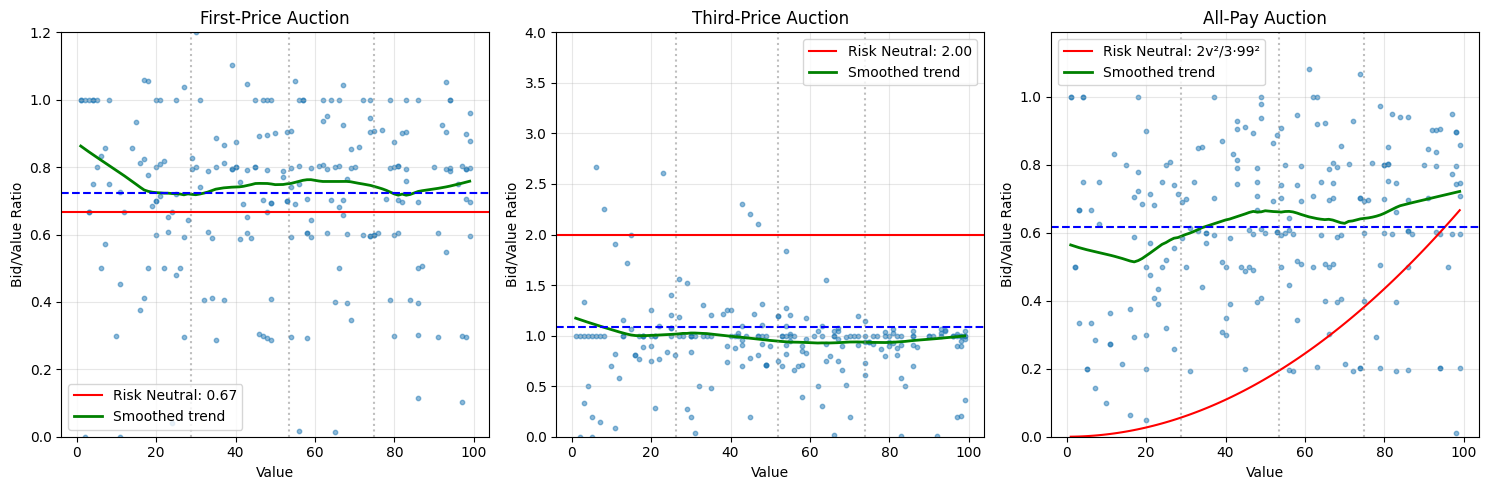

BID ANALYSIS RELATIVE TO AGENT VALUES

First-Price Auction (225 total bids)
--------------------------------------------------

EXACT COMPARISON:
1) Bids below agent value: 185 (82.22%)
2) Bids equal to agent value: 30 (13.33%)
3) Bids above agent value: 10 (4.44%)

WITH +/- 1 TOLERANCE:
1) Bids below agent value - 1: 178 (79.11%)
2) Bids within +/- 1 of agent value: 40 (17.78%)
3) Bids above agent value + 1: 7 (3.11%)

Second-Price Auction (225 total bids)
--------------------------------------------------

EXACT COMPARISON:
1) Bids below agent value: 148 (65.78%)
2) Bids equal to agent value: 49 (21.78%)
3) Bids above agent value: 28 (12.44%)

WITH +/- 1 TOLERANCE:
1) Bids below agent value - 1: 141 (62.67%)
2) Bids within +/- 1 of agent value: 58 (25.78%)
3) Bids above agent value + 1: 26 (11.56%)

Third-Price Auction (225 total bids)
--------------------------------------------------

EXACT COMPARISON:
1) Bids below agent value: 95 (42.22%)
2) Bids equal to agent value: 69 (30.67%)

In [ ]:
def analyze_bids_relative_to_values(all_dfs):
    """
    Analyze bids relative to agent values across all auction formats.
    For each auction, count bids below, equal to, and above agent values.
    Also counts using a +/- 1 tolerance around the agent value.
    
    Parameters:
    all_dfs (dict): Dictionary of dataframes for different auction formats
    
    Returns:
    dict: Analysis results for each auction format
    """
    results = {}
    
    for auction_key, df in all_dfs.items():
        below_value = 0
        equal_to_value = 0
        above_value = 0
        
        below_value_tol = 0z
        within_tolerance = 0
        above_value_tol = 0
        
        total_bids = 0
        
        for _, row in df.iterrows():
            values = row.get("Values", [])
            bids = row.get("Bids", [])
            
            for v, b in zip(values, bids):
                total_bids += 1
                
                # Exact comparisons
                if b < v:
                    below_value += 1
                elif b == v:
                    equal_to_value += 1
                else:  # b > v
                    above_value += 1
                
                # Tolerance-based comparisons (+/- 1)
                if b < (v - 1):
                    below_value_tol += 1
                elif (v - 1) <= b <= (v + 1):
                    within_tolerance += 1
                else:  # b > (v + 1)
                    above_value_tol += 1
        
        # Store results for this auction format
        results[auction_key] = {
            "exact": {
                "below_value": below_value,
                "equal_to_value": equal_to_value,
                "above_value": above_value,
                "total_bids": total_bids,
                "percentages": {
                    "below_value": round(below_value / total_bids * 100, 2) if total_bids > 0 else 0,
                    "equal_to_value": round(equal_to_value / total_bids * 100, 2) if total_bids > 0 else 0,
                    "above_value": round(above_value / total_bids * 100, 2) if total_bids > 0 else 0
                }
            },
            "tolerance": {
                "below_value_minus_1": below_value_tol,
                "within_plus_minus_1": within_tolerance,
                "above_value_plus_1": above_value_tol,
                "total_bids": total_bids,
                "percentages": {
                    "below_value_minus_1": round(below_value_tol / total_bids * 100, 2) if total_bids > 0 else 0,
                    "within_plus_minus_1": round(within_tolerance / total_bids * 100, 2) if total_bids > 0 else 0,
                    "above_value_plus_1": round(above_value_tol / total_bids * 100, 2) if total_bids > 0 else 0
                }
            }
        }
    
    return results

def print_analysis_results(results):
    """
    Print the analysis results in a readable format.
    
    Parameters:
    results (dict): Analysis results from analyze_bids_relative_to_values
    """
    auction_names = {
        "private_first": "First-Price Auction",
        "private_second": "Second-Price Auction",
        "private_third": "Third-Price Auction",
        "private_all_pay": "All-Pay Auction"
    }
    
    print("=" * 80)
    print("BID ANALYSIS RELATIVE TO AGENT VALUES")
    print("=" * 80)
    
    for auction_key, data in results.items():
        auction_name = auction_names.get(auction_key, auction_key)
        exact = data["exact"]
        tolerance = data["tolerance"]
        
        print(f"\n{auction_name} ({exact['total_bids']} total bids)")
        print("-" * 50)
        
        print("\nEXACT COMPARISON:")
        print(f"1) Bids below agent value: {exact['below_value']} ({exact['percentages']['below_value']}%)")
        print(f"2) Bids equal to agent value: {exact['equal_to_value']} ({exact['percentages']['equal_to_value']}%)")
        print(f"3) Bids above agent value: {exact['above_value']} ({exact['percentages']['above_value']}%)")
        
        print("\nWITH +/- 1 TOLERANCE:")
        print(f"1) Bids below agent value - 1: {tolerance['below_value_minus_1']} ({tolerance['percentages']['below_value_minus_1']}%)")
        print(f"2) Bids within +/- 1 of agent value: {tolerance['within_plus_minus_1']} ({tolerance['percentages']['within_plus_minus_1']}%)")
        print(f"3) Bids above agent value + 1: {tolerance['above_value_plus_1']} ({tolerance['percentages']['above_value_plus_1']}%)")
    
    print("\n" + "=" * 80)

# Example usage:
# results = analyze_bids_relative_to_values(all_dfs)
# print_analysis_results(results)

# To use both the plotting and analysis functions together:
def analyze_and_plot_auctions(all_dfs):
    """
    Run both the bid-value ratio plotting and bid analysis
    
    Parameters:
    all_dfs (dict): Dictionary of dataframes for different auction formats
    
    Returns:
    tuple: (plot figure, analysis results)
    """
    # Plot bid-value ratios
    fig = plot_bid_value_ratios(all_dfs)
    
    # Analyze bids relative to values
    results = analyze_bids_relative_to_values(all_dfs)
    print_analysis_results(results)
    
    return fig, results

# Run the combined analysis
fig, results = analyze_and_plot_auctions(all_dfs)

# CRRA robustness + heterogeneity checks


=== Heterogeneity Analysis by Value Range ===
 quartile value_range    slope  intercept     crra  n_obs
        0     [0, 24] 0.659552   0.718069 1.032360     49
        1    [25, 49] 0.748244  -0.341088 0.672926     56
        2    [50, 74] 0.824168  -5.818957 0.426690     63
        3    [75, 99] 0.773828  -6.539304 0.584555     54

Test for significant differences across quartiles:
F-statistic: 1.0793, p-value: 0.3587
Conclusion: No significant heterogeneity in CRRA across value ranges

=== Learning Effects Analysis ===

CRRA by Round:
 round      mean   median       std  count       se
     0  0.632957 0.285714  1.251341     15 0.323095
     1  0.226748 0.164706  0.243405     15 0.062847
     2  0.321911 0.227273  0.332239     15 0.085784
     3  0.862765 0.466667  1.092018     15 0.281958
     4  1.127845 0.480000  1.477101     15 0.381386
     5  1.022921 0.509091  1.233727     15 0.318547
     6  1.016985 0.882353  0.990693     15 0.255796
     7  0.614883 0.512821  0.512925   

/var/folders/qx/p3d0v1413yn2121qcx6nmklw0000gq/T/ipykernel_61447/158527499.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_from_regression = (n_bidders-1) * (1/model.params[1] - 1)
/var/folders/qx/p3d0v1413yn2121qcx6nmklw0000gq/T/ipykernel_61447/158527499.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'slope': model.params[1],
/var/folders/qx/p3d0v1413yn2121qcx6nmklw0000gq/T/ipykernel_61447/158527499.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value b

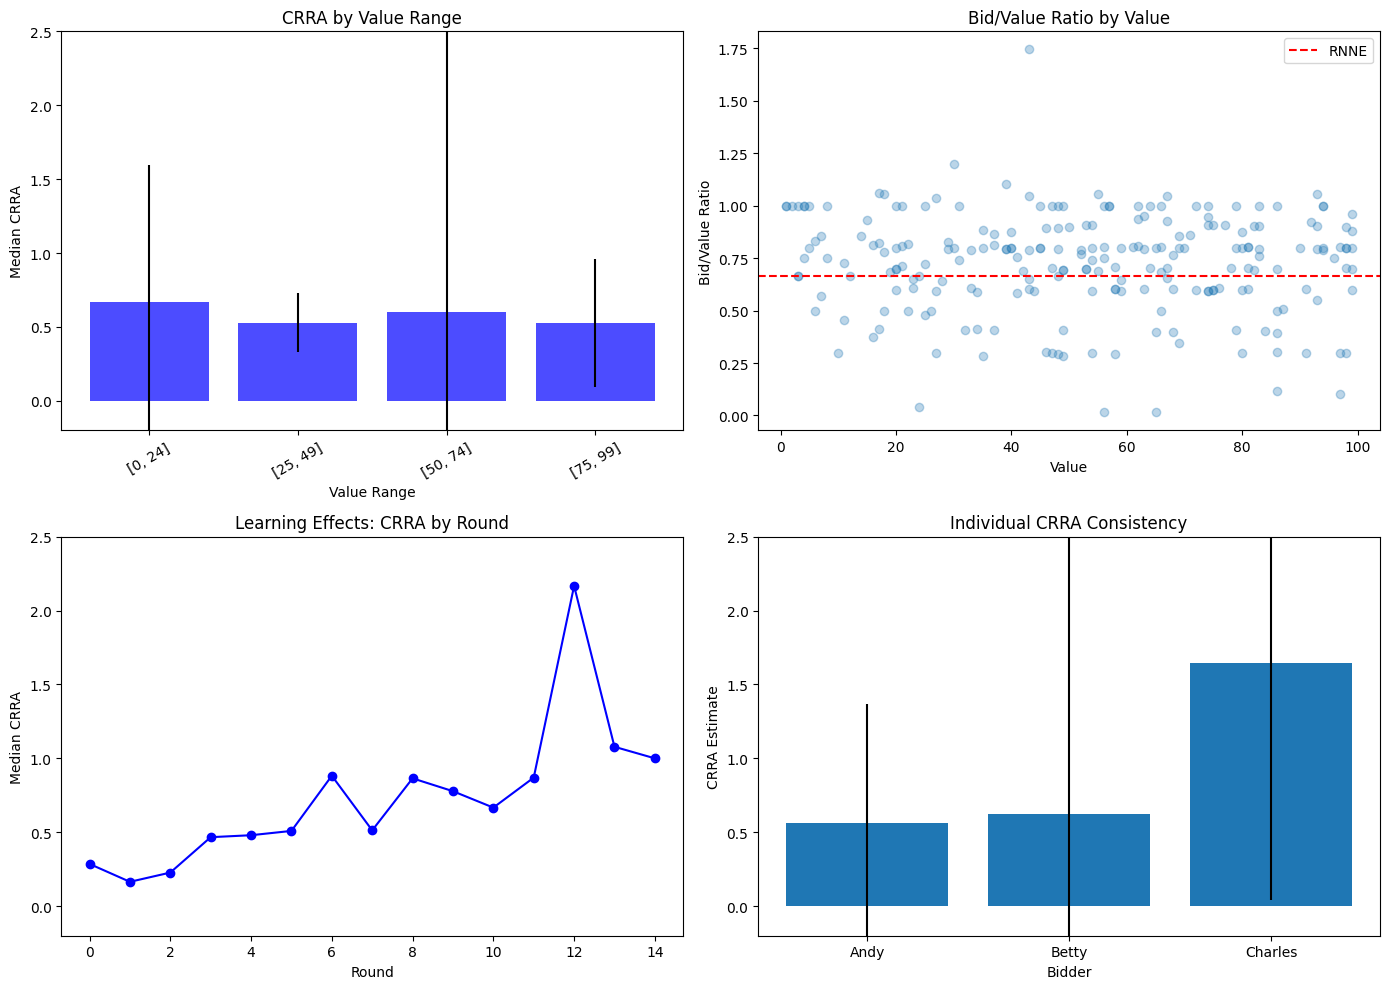

{'heterogeneity':    quartile value_range     slope  intercept  r_squared      crra  n_obs
 0         0     [0, 24]  0.659552   0.718069   0.658565  1.032360     49
 1         1    [25, 49]  0.748244  -0.341088   0.201323  0.672926     56
 2         2    [50, 74]  0.824168  -5.818957   0.143896  0.426690     63
 3         3    [75, 99]  0.773828  -6.539304   0.068146  0.584555     54,
 'learning':     round       mean    median        std  count        se
 0       0   0.632957  0.285714   1.251341     15  0.323095
 1       1   0.226748  0.164706   0.243405     15  0.062847
 2       2   0.321911  0.227273   0.332239     15  0.085784
 3       3   0.862765  0.466667   1.092018     15  0.281958
 4       4   1.127845  0.480000   1.477101     15  0.381386
 5       5   1.022921  0.509091   1.233727     15  0.318547
 6       6   1.016985  0.882353   0.990693     15  0.255796
 7       7   0.614883  0.512821   0.512925     15  0.132437
 8       8   1.363140  0.864865   1.441297     15  0.372141


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

def extended_crra_analysis(df, n_bidders=3):
   """
   Comprehensive analysis of CRRA estimates examining:
   1. Heterogeneity by value range
   2. Learning effects across rounds
   3. Individual consistency
   """
   # Extract bid-value pairs with round and bidder information
   data = []
   
   # Map bidder indices to names
   bidder_names = {0: "Bidder Andy", 1: "Bidder Betty", 2: "Bidder Charles"}
   
   for _, row in df.iterrows():
       round_num = row.get("Round")
       values = row.get("Values", [])
       bids = row.get("Bids", [])
       
       # Process each bidder's data using their position in the values/bids lists
       for i, (v, b) in enumerate(zip(values, bids)):
           if v > 0 and b > 0:
               # Use proper bidder name based on index
               bidder_name = bidder_names.get(i, f"Unknown Bidder {i}")
               
               # Calculate individual CRRA
               r_i = (n_bidders-1) * (v/b - 1)
               
               data.append({
                   'round': round_num,
                   'value': v,
                   'bid': b,
                   'bidder': bidder_name,
                   'bidder_index': i,
                   'bid_ratio': b/v,
                   'crra': r_i
               })
   
   # Convert to DataFrame for analysis
   analysis_df = pd.DataFrame(data)
   
   # 1. Heterogeneity Analysis by Value Range
   print("\n=== Heterogeneity Analysis by Value Range ===")
   
   # Create value quartiles with custom bin edges
   bin_edges = [0, 25, 50, 75, 100]
   analysis_df['value_quartile'] = pd.cut(analysis_df['value'], bins=bin_edges, labels=False, include_lowest=True)
   
   # CRRA by value quartile
   crra_by_quartile = analysis_df.groupby('value_quartile')['crra'].agg(['mean', 'median', 'std', 'count']).reset_index()
   crra_by_quartile['se'] = crra_by_quartile['std'] / np.sqrt(crra_by_quartile['count'])
   
   # Regression by quartile
   quartile_results = []
   for q in range(4):
       quartile_data = analysis_df[analysis_df['value_quartile'] == q]
       X = sm.add_constant(quartile_data['value'])
       model = sm.OLS(quartile_data['bid'], X).fit()
       
       r_from_regression = (n_bidders-1) * (1/model.params[1] - 1)
       quartile_results.append({
           'quartile': q,
           'value_range': f'[{bin_edges[q]}, {bin_edges[q+1]-1}]',
           'slope': model.params[1],
           'intercept': model.params[0],
           'r_squared': model.rsquared,
           'crra': r_from_regression,
           'n_obs': len(quartile_data)
       })
   
   quartile_df = pd.DataFrame(quartile_results)
   print(quartile_df[['quartile', 'value_range', 'slope', 'intercept', 'crra', 'n_obs']].to_string(index=False))
   
   # Test if CRRA differences across quartiles are significant
   f_stat, p_val = stats.f_oneway(*[analysis_df[analysis_df['value_quartile'] == q]['crra'] 
                                    for q in range(4)])
   print(f"\nTest for significant differences across quartiles:")
   print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")
   print(f"Conclusion: {'Significant heterogeneity' if p_val < 0.05 else 'No significant heterogeneity'} in CRRA across value ranges")
   
   # 2. Learning Effects Analysis
   print("\n=== Learning Effects Analysis ===")
   
   # CRRA by round
   crra_by_round = analysis_df.groupby('round')['crra'].agg(['mean', 'median', 'std', 'count']).reset_index()
   crra_by_round['se'] = crra_by_round['std'] / np.sqrt(crra_by_round['count'])
   
   print("\nCRRA by Round:")
   print(crra_by_round.to_string(index=False))
   
   # Regression to test for time trend in CRRA
   X = sm.add_constant(analysis_df['round'])
   trend_model = sm.OLS(analysis_df['crra'], X).fit()
   print("\nTime Trend Regression (CRRA = β₀ + β₁×Round):")
   print(f"Coefficient on Round: {trend_model.params[1]:.4f}")
   print(f"p-value: {trend_model.pvalues[1]:.4f}")
   print(f"Conclusion: {'Significant' if trend_model.pvalues[1] < 0.05 else 'No significant'} learning trend")
   
   # 3. Individual Consistency Analysis
   print("\n=== Individual Consistency Analysis ===")
   
   # Identify bidders with sufficient observations
   bidder_counts = analysis_df['bidder'].value_counts()
   consistent_bidders = bidder_counts[bidder_counts >= 10].index
   
   if len(consistent_bidders) >= 2:
       individual_results = []
       
       for bidder in consistent_bidders:
           bidder_data = analysis_df[analysis_df['bidder'] == bidder]
           X = sm.add_constant(bidder_data['value'])
           model = sm.OLS(bidder_data['bid'], X).fit()
           
           r_from_regression = (n_bidders-1) * (1/model.params[1] - 1)
           crra_std = bidder_data['crra'].std()
           
           individual_results.append({
               'bidder': bidder,
               'slope': model.params[1],
               'intercept': model.params[0],
               'crra': r_from_regression,
               'crra_std': crra_std,
               'n_obs': len(bidder_data)
           })
       
       indiv_df = pd.DataFrame(individual_results)
       print("\nIndividual Bidder Analysis:")
       print(indiv_df[['bidder', 'slope', 'crra', 'crra_std', 'n_obs']].to_string(index=False))
       
       # Test if differences between bidders are significant
       f_stat, p_val = stats.f_oneway(*[analysis_df[analysis_df['bidder'] == b]['crra'] 
                                        for b in consistent_bidders])
       print(f"\nTest for significant differences across bidders:")
       print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")
       print(f"Conclusion: {'Significant heterogeneity' if p_val < 0.05 else 'No significant heterogeneity'} in CRRA across bidders")
   else:
       print("Insufficient data to analyze individual consistency")
       indiv_df = None
   
   # Create visualizations
   fig, axes = plt.subplots(2, 2, figsize=(14, 10))
   
   # 1. CRRA by value quartile - with range labels and error bars
   # Sort quartile results to ensure correct order
   quartile_df_sorted = quartile_df.sort_values('quartile')
   
   # Create sorted labels
   quartile_labels = quartile_df_sorted['value_range'].tolist()
   
   # Reorder the CRRA by quartile data to match sorted quartiles
   crra_by_quartile_sorted = crra_by_quartile.sort_values('value_quartile')
   
   axes[0, 0].bar(range(len(quartile_labels)), 
                  crra_by_quartile_sorted['median'], 
                  color='blue', 
                  alpha=0.7, 
                  yerr=crra_by_quartile_sorted['se'])
   axes[0, 0].set_xticks(range(len(quartile_labels)))
   axes[0, 0].set_xticklabels(quartile_labels, rotation=30)
   axes[0, 0].set_xlabel('Value Range')
   axes[0, 0].set_ylabel('Median CRRA')
   axes[0, 0].set_title('CRRA by Value Range')
   axes[0, 0].set_ylim(-0.2, 2.5)  # Set y-axis limits
   
   # 2. Bid/Value ratio by value
   axes[0, 1].scatter(analysis_df['value'], analysis_df['bid_ratio'], alpha=0.3)
   axes[0, 1].axhline(y=2/3, color='r', linestyle='--', label='RNNE')
   axes[0, 1].set_xlabel('Value')
   axes[0, 1].set_ylabel('Bid/Value Ratio')
   axes[0, 1].set_title('Bid/Value Ratio by Value')
   axes[0, 1].legend()
   
   # 3. CRRA by round - Median only
   axes[1, 0].plot(crra_by_round['round'], crra_by_round['median'], marker='o', color='blue')
   axes[1, 0].set_xlabel('Round')
   axes[1, 0].set_ylabel('Median CRRA')
   axes[1, 0].set_title('Learning Effects: CRRA by Round')
   axes[1, 0].set_ylim(-0.2, 2.5)  # Set y-axis limits
   
   # 4. Individual CRRA comparison - with correct bidder order
   if indiv_df is not None and len(indiv_df) >= 2:
       # Sort bidders in the correct order: Andy, Betty, Charles
       correct_order = [name for name in ["Bidder Andy", "Bidder Betty", "Bidder Charles"] 
                        if name in indiv_df['bidder'].values]
       
       # Filter and sort the dataframe
       ordered_df = indiv_df[indiv_df['bidder'].isin(correct_order)].copy()
       ordered_df['sort_key'] = ordered_df['bidder'].map({name: i for i, name in enumerate(correct_order)})
       ordered_df = ordered_df.sort_values('sort_key')
       
       # Plot with shorter labels
       axes[1, 1].bar(range(len(ordered_df)), ordered_df['crra'], yerr=ordered_df['crra_std'])
       axes[1, 1].set_xticks(range(len(ordered_df)))
       axes[1, 1].set_xticklabels([name.replace('Bidder ', '') for name in ordered_df['bidder']])
       axes[1, 1].set_xlabel('Bidder')
       axes[1, 1].set_ylabel('CRRA Estimate')
       axes[1, 1].set_title('Individual CRRA Consistency')
       axes[1, 1].set_ylim(-0.2, 2.5)  # Set y-axis limits
   
   plt.tight_layout()
   plt.show()
   
   return {
       'heterogeneity': quartile_df,
       'learning': crra_by_round,
       'individual': indiv_df,
       'raw_data': analysis_df
   }

results = extended_crra_analysis(all_dfs["private_first"])
results

# Investigating plans

In [21]:
import scipy.stats as stats
import numpy as np
import pandas as pd

# Assuming all_dfs is a dictionary of DataFrames with auction results
interventions = {
    "private_first": "private_first_price",
    "private_second": "private_second_price",
    "private_third": "private_third_price",
    "private_all_pay": "private_all_pay"
}

# Extract bid distributions and flatten lists
bids = {key: all_dfs[key]["Bids"].explode().dropna().astype(float) for key in interventions}

# Perform KS tests between each pair of distributions
ks_results = {}
for key1 in bids:
    for key2 in bids:
        if key1 < key2:  # Avoid redundant comparisons
            ks_stat, ks_pval = stats.ks_2samp(bids[key1], bids[key2])
            ks_results[(key1, key2)] = (ks_stat, ks_pval)

# Perform Chi-squared tests (categorizing bids into bins)
chi_results = {}
bins = list(range(0, 101, 10))  # Adjust bin size as needed
for key1 in bids:
    for key2 in bids:
        if key1 < key2:
            hist1, _ = np.histogram(bids[key1], bins=bins)
            hist2, _ = np.histogram(bids[key2], bins=bins)

            # Normalize frequencies to have the same sum
            hist1 = hist1 / hist1.sum() * hist2.sum()  # Scale hist1 to match hist2's total count

            chi_stat, chi_pval = stats.chisquare(hist1, hist2)
            chi_results[(key1, key2)] = (chi_stat, chi_pval)

# Display KS and Chi-squared test results
# import ace_tools as tools
ks_df = pd.DataFrame(ks_results, index=["KS Statistic", "p-value"]).T
chi_df = pd.DataFrame(chi_results, index=["Chi-Square Statistic", "p-value"]).T

# tools.display_dataframe_to_user(name="Kolmogorov-Smirnov Test Results", dataframe=ks_df)
# tools.display_dataframe_to_user(name="Chi-Squared Test Results", dataframe=chi_df)


In [22]:
ks_df

KS Statistic   p-value
private_first   private_second      0.084444  0.399460
                private_third       0.151111  0.011646
private_second  private_third       0.097778  0.232672
private_all_pay private_first       0.111111  0.124382
                private_second      0.160000  0.006228
                private_third       0.222222  0.000028

In [24]:
chi_df

Chi-Square Statistic       p-value
private_first   private_second             22.965986  6.273162e-03
                private_third              35.676379  4.524554e-05
private_second  private_third              36.665938  3.018663e-05
private_all_pay private_first              11.170033  2.642339e-01
                private_second             24.694559  3.328301e-03
                private_third              59.461705  1.702140e-09

In [16]:
import scipy.stats as stats
import numpy as np
import pandas as pd

# Assuming all_dfs is a dictionary of DataFrames with auction results
interventions = {
    "private_first": "private_first_price",
    "private_second": "private_second_price",
    "private_third": "private_third_price",
    "private_all_pay": "private_all_pay"
}

# Extract bid distributions and flatten lists
bids = {key: all_dfs[key]["Bids"].explode().dropna().astype(float) for key in interventions}

# Perform KS tests between each pair of distributions
ks_results = {}
for key1 in bids:
    for key2 in bids:
        if key1 < key2:  # Avoid redundant comparisons
            ks_stat, ks_pval = stats.ks_2samp(bids[key1], bids[key2])
            ks_results[(key1, key2)] = (ks_stat, ks_pval)

# Perform Chi-squared tests (categorizing bids into bins)
chi_results = {}
bins = list(range(0, 101, 10))  # Adjust bin size as needed
for key1 in bids:
    for key2 in bids:
        if key1 < key2:
            hist1, _ = np.histogram(bids[key1], bins=bins, density=True)  # Normalize
            hist2, _ = np.histogram(bids[key2], bins=bins, density=True)  # Normalize

            chi_stat, chi_pval = stats.chisquare(hist1, hist2)
            chi_results[(key1, key2)] = (chi_stat, chi_pval)

# Convert results to DataFrames for display
ks_df = pd.DataFrame(ks_results, index=["KS Statistic", "p-value"]).T
chi_df = pd.DataFrame(chi_results, index=["Chi-Square Statistic", "p-value"]).T

In [ ]:
all_dfs["private_all_pay"]["Bids"].explode().dropna().astype(float)


,exp_name,file_id,Round,Values,Bids,Winner Index,Winner Name,Realized Common Value,Bid Paid by Winner,Winner Total Profit
0,private_all_pay,0,0,"[93, 56, 5]","[74, 11, 1]",0,Bidder Andy,0,74,19.0
1,private_all_pay,0,1,"[92, 20, 63]","[83, 4, 63]",0,Bidder Andy,0,83,9.0
2,private_all_pay,0,2,"[54, 72, 21]","[40, 14, 15]",0,Bidder Andy,0,40,14.0
3,private_all_pay,0,3,"[35, 62, 58]","[21, 44, 20]",1,Bidder Betty,0,44,18.0
4,private_all_pay,0,4,"[46, 99, 35]","[23, 70, 20]",1,Bidder Betty,0,70,29.0
...,...,...,...,...,...,...,...,...,...,...
70,private_all_pay,4,10,"[54, 82, 18]","[38, 49, 13]",1,Bidder Betty,0,49,33.0
71,private_all_pay,4,11,"[27, 87, 1]","[7, 52, 1]",1,Bidder Betty,0,52,35.0
72,private_all_pay,4,12,"[91, 78, 72]","[77, 23, 67]",0,Bidder Andy,0,77,14.0
73,private_all_pay,4,13,"[75, 39, 34]","[45, 12, 29]",0,Bidder Andy,0,45,30.0


In [28]:
import pandas as pd

# Load the dataframe from the provided image structure
df = all_dfs["private_all_pay"].copy()

# Explode 'Values' and 'Bids' columns
df_exploded = df[['Values', 'Bids']].explode(['Values', 'Bids']).dropna().astype(float)

# Compute the bid implied by the BNE for each value
df_exploded['BNE_Bid'] = (2 / (3 * 99**2)) * df_exploded['Values']**3

# Compute the share of bids that fall between BNE_Bid and Value
df_exploded['Valid_Bid'] = df_exploded.apply(lambda row: row['BNE_Bid'] <= row['Bids'] <= row['Values'], axis=1)

# Compute the share
share_valid_bids = df_exploded['Valid_Bid'].mean()

share_valid_bids


0.8977777777777778

In [ ]:
ks_df

KS Statistic   p-value
private_first   private_second      0.084444  0.399460
                private_third       0.151111  0.011646
private_second  private_third       0.097778  0.232672
private_all_pay private_first       0.111111  0.124382
                private_second      0.160000  0.006228
                private_third       0.222222  0.000028

In [18]:
chi_df

Chi-Square Statistic  p-value
private_first   private_second              0.010299      1.0
                private_third               0.015927      1.0
private_second  private_third               0.016369      1.0
private_all_pay private_first               0.004964      1.0
                private_second              0.011074      1.0
                private_third               0.026545      1.0